In [1]:
import cfe

cfe.logger.setLevel("DEBUG")
cfe.settings.backend = "cfe_docker"

[10/27/2025 11:31:02] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

                      DEBUG    Reading data from '/root/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad'...                                                                                      
[10/27/2025 11:31:03] DEBUG    transfer 'X' and 'Spliced' matrix from csr to csc for better dynverse docker performance                                                                                 
                      DEBUG    Create a FateAnnData object from an existing AnnData object.                                                                                                             
                      DEBUG    recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                  
                      DEBUG    recognize 'X_umap' in '.obsm' keys as 'basis' key                                                                                                                    

<Axes: title={'center': 'ref(clusters)'}, xlabel='X_umap1', ylabel='X_umap2'>

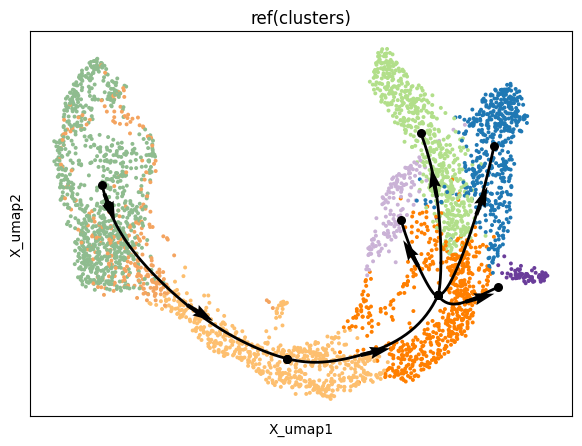

In [2]:
fadata = cfe.data.read_pancrease()
cfe.plot.plot_trajectory(fadata)

In [3]:
method2parameters = {
    "scvelo": {},
    "palantir": {},
    "stavia": {},
}

for method_name, parameters in method2parameters.items():
    parameters["repreprocess"] = False # use common preprocessing
    parameters["benchmark_resource"] = True # record resource usage
    method = cfe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata, parameters=parameters)
    

                      DEBUG    CFEDockerBackend __init__                                                                                                                                                
                      DEBUG    Docker image(huangzhaoyang/scvelo:0.0.1) loaded, entry point is 'None'                                                                                                   
                      DEBUG    Loaded function 'scvelo': <function scvelo at 0x7f71149e5bd0>                                                                                                            
                      INFO     method backend loaded: CFE Docker Backend: scvelo in docker image 'huangzhaoyang/scvelo:0.0.1'                                                                           
                      DEBUG    merged parameters: {'repreprocess': False}                                                                                                                           

                      DEBUG    extract 'X_umap' from prior infomation as parameter 'basis'                                                                                                              
                      DEBUG    plot_trajectory                                                                                                                                                          
                      DEBUG    'ref' is not a valid random_time_string, don't need parse                                                                                                                
                      DEBUG    plot_trajectory                                                                                                                                                          
[10/27/2025 11:33:17] DEBUG    'ref' is not a valid random_time_string, don't need parse                                                                                                            

<Axes: title={'center': 'stavia-cfe_docker(milestone)'}, xlabel='X_umap1', ylabel='X_umap2'>

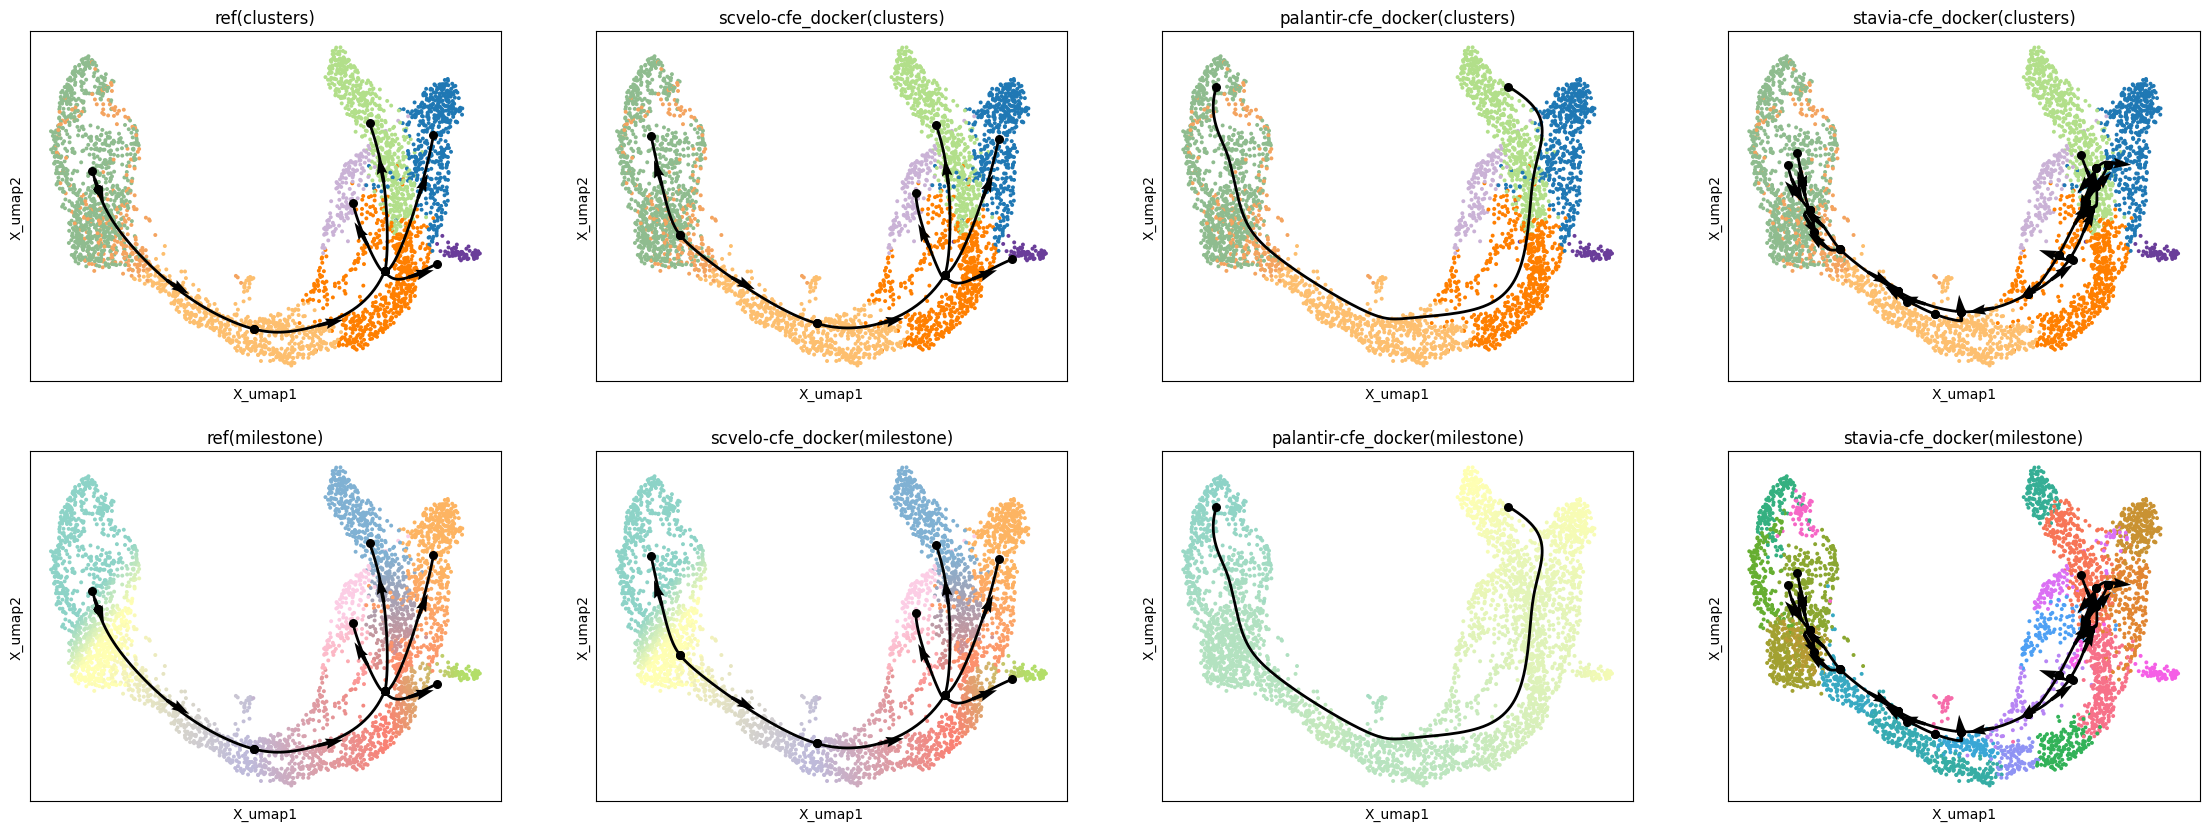

In [4]:
model_name_list = fadata.get_all_model_name(parse=False)
color_list = ["clusters", "milestone"]

cfe.plot.plot_trajectory(fadata, model_name=model_name_list, color=color_list)

In [5]:
fadata.write_trajectory_dict()

[10/27/2025 11:35:50] DEBUG    write trajectory 'ref' to '.cfe/trajectory_history/pancreas/ref.pkl'                                                                                                     
                      DEBUG    write trajectory '20251027_113107__scvelo-cfe_docker__ixvmqI5sTG' to '.cfe/trajectory_history/pancreas/20251027_113107__scvelo-cfe_docker__ixvmqI5sTG.pkl'               
[10/27/2025 11:35:51] DEBUG    write trajectory '20251027_113203__palantir-cfe_docker__KZ09bCCcFo' to '.cfe/trajectory_history/pancreas/20251027_113203__palantir-cfe_docker__KZ09bCCcFo.pkl'           
                      DEBUG    write trajectory '20251027_113240__stavia-cfe_docker__j0LT2KQ9PJ' to '.cfe/trajectory_history/pancreas/20251027_113240__stavia-cfe_docker__j0LT2KQ9PJ.pkl'               
